In [ ]:
!pip -q install qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import scipy as sp
import requests
import math
import json
import time
import os
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from IPython.display import display, Markdown

In [ ]:
os.makedirs("results", exist_ok=True)
print("Created/checked: results/")

Created/checked: results/


In [ ]:
# Current Quokka address from the provided notebook
req_str_qasm = 'http://quokka1.quokkacomputing.com/qsim/qasm'

In [ ]:
def qubit_learner(angle, count=1000):
    qasm = '''
    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[1];
    creg result[1];
    rx({}) q[0];
    measure q[0] -> result[0];
    '''.format(angle[0])

    data = {
        'count': count,
        'script': qasm
    }

    result = requests.post(req_str_qasm, json=data, timeout=60)
    json_obj = json.loads(result.content)
    return np.mean(json_obj['result']['result'])

def objective_function(angle, bit=1):
    error = bit - qubit_learner(angle)
    return np.abs(error) ** 2

In [ ]:
warmup_result = sp.optimize.minimize(
    objective_function,
    x0=np.random.randn(1),
    method='Nelder-Mead',
    options={'maxiter': 10}
)

print(warmup_result)

       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 0.913936
             x: [ 3.608e-01]
           nit: 10
          nfev: 28
 final_simplex: (array([[ 3.608e-01],
                       [ 3.608e-01]]), array([ 9.139e-01,  9.526e-01]))


In [ ]:
def generate_binary_code(bit_length):
    bit_combinations = np.zeros((int(2**bit_length), bit_length))
    for number in range(int(2**bit_length)):
        dividend = number
        bit_index = 0
        while dividend != 0:
            bit_combinations[number, bit_index] = np.remainder(dividend, 2)
            dividend = np.floor_divide(dividend, 2)
            bit_index += 1
    return bit_combinations

def generate_data(length):
    stripes = generate_binary_code(length)
    stripes = np.repeat(stripes, length, 0)
    stripes = stripes.reshape(2 ** length, length * length)

    bars = generate_binary_code(length)
    bars = bars.reshape(2 ** length * length, 1)
    bars = np.repeat(bars, length, 1)
    bars = bars.reshape(2 ** length, length * length)

    return np.vstack((stripes[1:stripes.shape[0]-1], bars[1:bars.shape[0]-1]))

In [ ]:
length = 2
dataset = generate_data(length)
labels = np.concatenate((np.zeros(int(2**length - 2)), np.ones(int(2**length - 2))))
n_parameters = int(2 * (length**2 - 1))

print("Dataset shape:", dataset.shape)
print("Labels shape:", labels.shape)
print("Number of trainable parameters:", n_parameters)

Dataset shape: (4, 4)
Labels shape: (4,)
Number of trainable parameters: 6


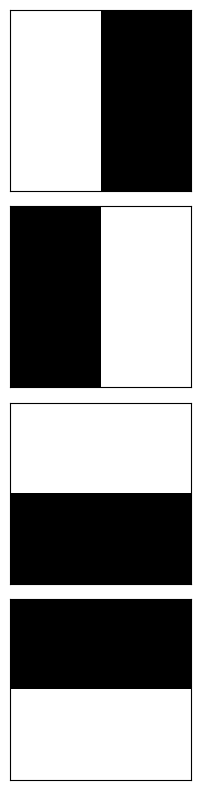

Saved: results/task4_dataset_examples.png


In [ ]:
plt.figure(figsize=[8, 8])
j = 1
for i in dataset:
    plt.subplot(4, int(2**(length-1) - 1), j)
    j += 1
    plt.imshow(np.reshape(i, [length, length]), cmap="gray")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.savefig("results/task4_dataset_examples.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: results/task4_dataset_examples.png")

In [ ]:
np.random.seed(42)

selected_indices = np.random.choice(
    dataset.shape[0],
    int(dataset.shape[0] * 0.75),
    replace=False
)

all_indices = np.arange(dataset.shape[0])
unselected_indices = np.setdiff1d(all_indices, selected_indices)

training = dataset[selected_indices]
training_labels = labels[selected_indices]
test = dataset[unselected_indices]
test_labels = labels[unselected_indices]

print("Training samples:", len(training))
print("Test samples:", len(test))
print("Training labels:", training_labels)
print("Test labels:", test_labels)

Training samples: 3
Test samples: 1
Training labels: [0. 1. 0.]
Test labels: [1.]


In [ ]:
def block(angles, qubits):
    qasm = '''
    ry({}) q[{}];
    ry({}) q[{}];
    cx q[{}], q[{}];
    '''.format(
        angles[0], qubits[0],
        angles[1], qubits[1],
        qubits[0], qubits[1]
    )
    return qasm

In [ ]:
def generate_pairs(mylist, start, end):
    if start >= end:
        return

    mid = (start + end - 1) // 2

    generate_pairs(mylist, start, mid)
    generate_pairs(mylist, mid + 1, end)

    mylist.append((mid, end))

In [ ]:
def create_circuit(data, angles):
    length = data.shape[0]

    qasm = '''
    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[{}];
    creg c[1];
    '''.format(length)

    # Encode binary image into qubits using X gates
    for i in range(length):
        if data[i] > 0.5:
            qasm += '''
    x q[{}];
    '''.format(i)

    # Generate recursive entangling pairs
    pairs = []
    generate_pairs(pairs, 0, length - 1)

    count = 0
    for (i, j) in pairs:
        qasm += block([angles[count], angles[count + 1]], [i, j])
        count += 2

    # Measure final qubit only
    qasm += '''
    measure q[{}] -> c[0];
    '''.format(length - 1)

    return qasm

In [ ]:
sample_qasm = create_circuit(dataset[0], np.zeros(n_parameters))
print(sample_qasm)

with open("results/task4_sample_qasm.txt", "w") as f:
    f.write(sample_qasm)

print("Saved: results/task4_sample_qasm.txt")


    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[4];
    creg c[1];
    
    x q[0];
    
    x q[2];
    
    ry(0.0) q[0];
    ry(0.0) q[1];
    cx q[0], q[1];
    
    ry(0.0) q[2];
    ry(0.0) q[3];
    cx q[2], q[3];
    
    ry(0.0) q[1];
    ry(0.0) q[3];
    cx q[1], q[3];
    
    measure q[3] -> c[0];
    
Saved: results/task4_sample_qasm.txt


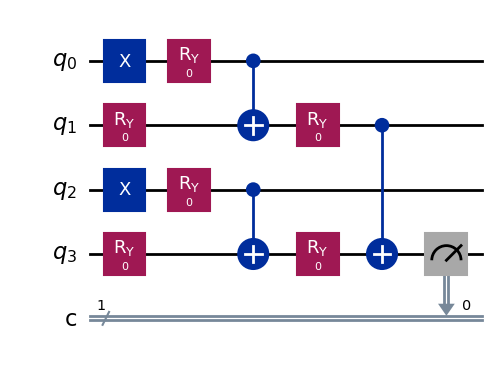

Saved: results/task4_qiskit_equivalent_circuit.png


In [ ]:
def build_qiskit_circuit(data, angles):
    n = len(data)
    qc = QuantumCircuit(n, 1)

    # Encode data
    for i in range(n):
        if data[i] > 0.5:
            qc.x(i)

    # Recursive pairs
    pairs = []
    generate_pairs(pairs, 0, n - 1)

    count = 0
    for (i, j) in pairs:
        qc.ry(angles[count], i)
        qc.ry(angles[count + 1], j)
        qc.cx(i, j)
        count += 2

    qc.measure(n - 1, 0)
    return qc

qc_vis = build_qiskit_circuit(dataset[0], np.zeros(n_parameters))
fig = qc_vis.draw("mpl")
fig.savefig("results/task4_qiskit_equivalent_circuit.png", dpi=200, bbox_inches="tight")
plt.close(fig)

display(qc_vis.draw("mpl"))
print("Saved: results/task4_qiskit_equivalent_circuit.png")

In [ ]:
def objective_quokka(x, dataset, labels, count=100):
    n_data = dataset.shape[0]
    to_return = 0

    for idx in range(n_data):
        qasm = create_circuit(dataset[idx], x)

        data = {
            'count': count,
            'script': qasm
        }

        result = requests.post(req_str_qasm, json=data, timeout=60)
        values = json.loads(result.content)['result']['c']

        to_return += np.abs(np.mean(values) - labels[idx])

    return to_return / n_data

In [ ]:
def spsa_tracked(func, x0, a=0.1, c=0.01, alpha=0.602, gamma=0.101, maxiter=30, verbose=False):
    k = 0
    x = x0.copy()

    history = {
        "iteration": [],
        "loss": [],
        "time_sec": []
    }

    while k < maxiter:
        start_time = time.time()

        ak = a / (k + 1) ** alpha
        ck = c / (k + 1) ** gamma

        delta = 2 * np.random.randint(0, 2, len(x0)) - 1

        xp = x + ck * delta
        xm = x - ck * delta

        fp = func(xp)
        fm = func(xm)

        grad = (fp - fm) / (2 * ck) * delta
        x = x - ak * grad

        fx = func(x)

        elapsed = time.time() - start_time

        history["iteration"].append(k)
        history["loss"].append(fx)
        history["time_sec"].append(elapsed)

        if verbose:
            print(f"Iteration {k}: loss = {fx:.6f}, time = {elapsed:.4f} sec")

        k += 1

    return x, history

In [ ]:
f_quokka = lambda x: objective_quokka(x, training, training_labels, count=100)

np.random.seed(42)
x0 = np.pi * np.random.randn(n_parameters)

a = 1.0
c = 0.5
alpha = 0.602
gamma = 0.101
maxiter = 20   # safer for Quokka runtime

xsol_quokka, history_quokka = spsa_tracked(
    f_quokka,
    x0,
    a=a,
    c=c,
    alpha=alpha,
    gamma=gamma,
    maxiter=maxiter,
    verbose=True
)

Iteration 0: loss = 0.376667, time = 3.9387 sec
Iteration 1: loss = 0.436667, time = 4.0496 sec
Iteration 2: loss = 0.380000, time = 3.8685 sec
Iteration 3: loss = 0.363333, time = 3.8146 sec
Iteration 4: loss = 0.250000, time = 3.8306 sec
Iteration 5: loss = 0.270000, time = 3.7785 sec
Iteration 6: loss = 0.210000, time = 3.7979 sec
Iteration 7: loss = 0.220000, time = 3.9157 sec
Iteration 8: loss = 0.230000, time = 3.7712 sec
Iteration 9: loss = 0.226667, time = 3.7557 sec
Iteration 10: loss = 0.180000, time = 3.8307 sec
Iteration 11: loss = 0.180000, time = 3.7547 sec
Iteration 12: loss = 0.186667, time = 3.8126 sec
Iteration 13: loss = 0.170000, time = 3.7960 sec
Iteration 14: loss = 0.193333, time = 3.8327 sec
Iteration 15: loss = 0.143333, time = 3.7316 sec
Iteration 16: loss = 0.146667, time = 3.8206 sec
Iteration 17: loss = 0.146667, time = 3.7281 sec
Iteration 18: loss = 0.133333, time = 4.0102 sec
Iteration 19: loss = 0.150000, time = 3.6128 sec


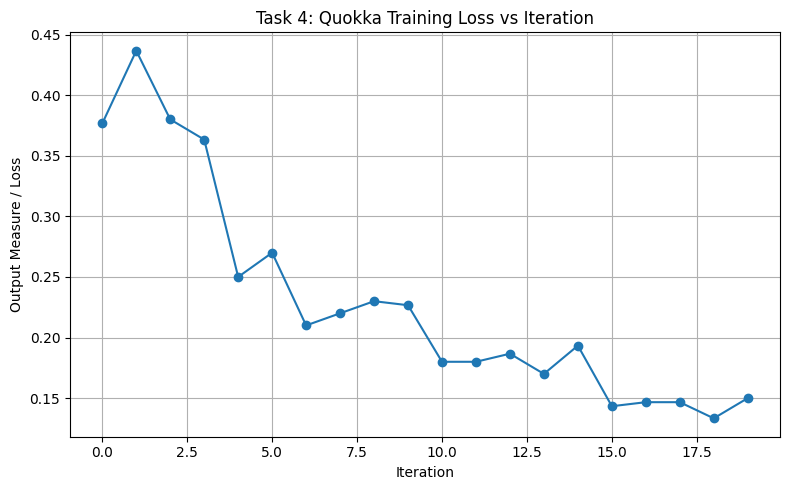

Saved: results/task4_quokka_loss_curve.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_quokka["iteration"], history_quokka["loss"], marker='o')
plt.xlabel("Iteration")
plt.ylabel("Output Measure / Loss")
plt.title("Task 4: Quokka Training Loss vs Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/task4_quokka_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: results/task4_quokka_loss_curve.png")

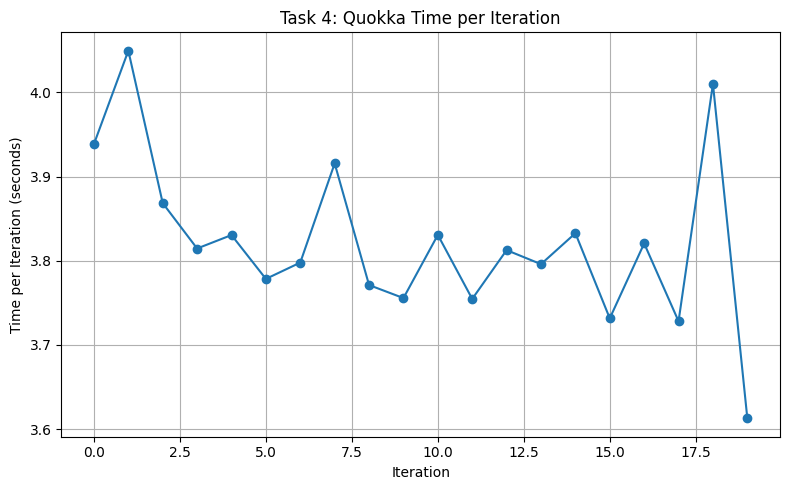

Saved: results/task4_quokka_time_curve.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_quokka["iteration"], history_quokka["time_sec"], marker='o')
plt.xlabel("Iteration")
plt.ylabel("Time per Iteration (seconds)")
plt.title("Task 4: Quokka Time per Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/task4_quokka_time_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: results/task4_quokka_time_curve.png")

In [ ]:
simulator = AerSimulator()

def circuit_prediction_local(data, angles, shots=100):
    qc = build_qiskit_circuit(data, angles)

    job = simulator.run(qc, shots=shots)
    result = job.result()
    counts = result.get_counts()

    ones = counts.get('1', 0)
    prob_one = ones / shots

    return prob_one

In [ ]:
def objective_local(x, dataset, labels, count=100):
    n_data = dataset.shape[0]
    to_return = 0

    for idx in range(n_data):
        pred = circuit_prediction_local(dataset[idx], x, shots=count)
        to_return += np.abs(pred - labels[idx])

    return to_return / n_data

In [ ]:
f_local = lambda x: objective_local(x, training, training_labels, count=100)

np.random.seed(42)
x0_local = np.pi * np.random.randn(n_parameters)

xsol_local, history_local = spsa_tracked(
    f_local,
    x0_local,
    a=a,
    c=c,
    alpha=alpha,
    gamma=gamma,
    maxiter=maxiter,
    verbose=True
)

Iteration 0: loss = 0.396667, time = 0.0150 sec
Iteration 1: loss = 0.423333, time = 0.0088 sec
Iteration 2: loss = 0.386667, time = 0.0156 sec
Iteration 3: loss = 0.356667, time = 0.0106 sec
Iteration 4: loss = 0.226667, time = 0.0113 sec
Iteration 5: loss = 0.290000, time = 0.1816 sec
Iteration 6: loss = 0.313333, time = 0.0207 sec
Iteration 7: loss = 0.253333, time = 0.0150 sec
Iteration 8: loss = 0.256667, time = 0.0108 sec
Iteration 9: loss = 0.263333, time = 0.0092 sec
Iteration 10: loss = 0.190000, time = 0.0085 sec
Iteration 11: loss = 0.166667, time = 0.0091 sec
Iteration 12: loss = 0.206667, time = 0.0083 sec
Iteration 13: loss = 0.203333, time = 0.0088 sec
Iteration 14: loss = 0.146667, time = 0.0105 sec
Iteration 15: loss = 0.173333, time = 0.0104 sec
Iteration 16: loss = 0.203333, time = 0.0084 sec
Iteration 17: loss = 0.133333, time = 0.0083 sec
Iteration 18: loss = 0.143333, time = 0.0086 sec
Iteration 19: loss = 0.120000, time = 0.0092 sec


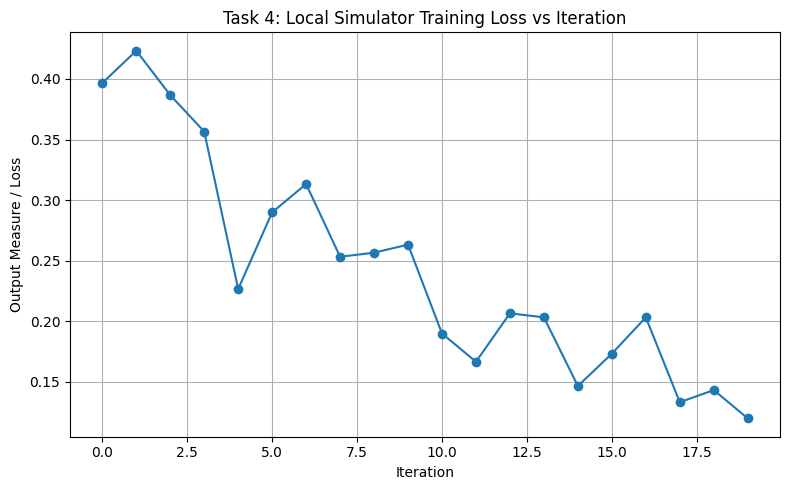

Saved: results/task4_local_loss_curve.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_local["iteration"], history_local["loss"], marker='o')
plt.xlabel("Iteration")
plt.ylabel("Output Measure / Loss")
plt.title("Task 4: Local Simulator Training Loss vs Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/task4_local_loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: results/task4_local_loss_curve.png")

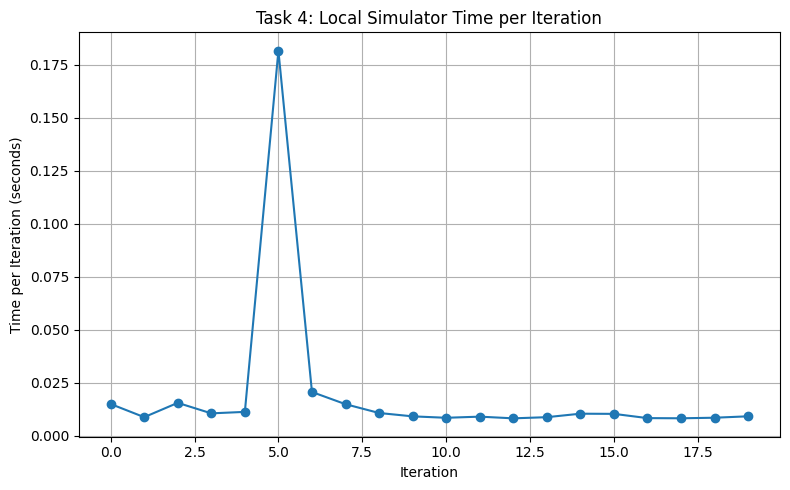

Saved: results/task4_local_time_curve.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_local["iteration"], history_local["time_sec"], marker='o')
plt.xlabel("Iteration")
plt.ylabel("Time per Iteration (seconds)")
plt.title("Task 4: Local Simulator Time per Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/task4_local_time_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: results/task4_local_time_curve.png")

In [ ]:
quokka_final_loss = history_quokka["loss"][-1]
local_final_loss = history_local["loss"][-1]

quokka_avg_time = np.mean(history_quokka["time_sec"])
local_avg_time = np.mean(history_local["time_sec"])

print("=== Final Comparison ===")
print(f"Quokka final loss: {quokka_final_loss:.6f}")
print(f"Local final loss:  {local_final_loss:.6f}")
print(f"Quokka avg iteration time: {quokka_avg_time:.4f} sec")
print(f"Local avg iteration time:  {local_avg_time:.4f} sec")

=== Final Comparison ===
Quokka final loss: 0.150000
Local final loss:  0.120000
Quokka avg iteration time: 3.8225 sec
Local avg iteration time:  0.0194 sec


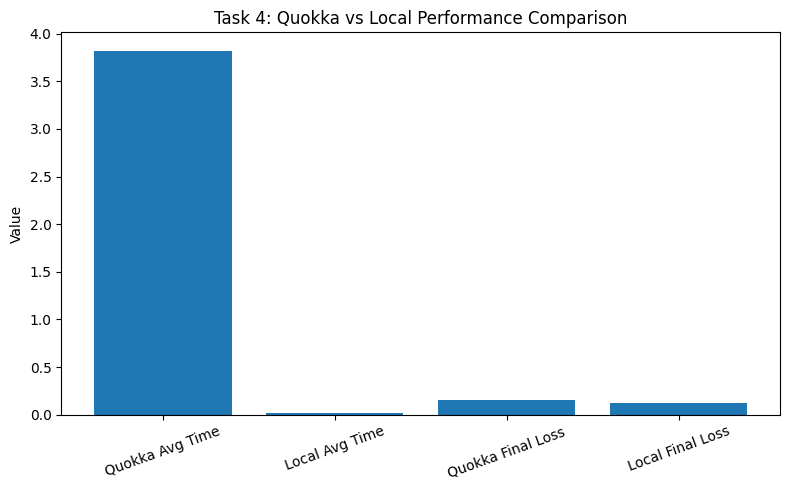

Saved: results/task4_comparison_bar.png


In [ ]:
plt.figure(figsize=(8, 5))
x_labels = ["Quokka Avg Time", "Local Avg Time", "Quokka Final Loss", "Local Final Loss"]
y_vals = [quokka_avg_time, local_avg_time, quokka_final_loss, local_final_loss]

plt.bar(x_labels, y_vals)
plt.ylabel("Value")
plt.title("Task 4: Quokka vs Local Performance Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("results/task4_comparison_bar.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: results/task4_comparison_bar.png")

In [ ]:
test_loss_quokka = objective_quokka(xsol_quokka, test, test_labels, count=100)
test_loss_local = objective_local(xsol_local, test, test_labels, count=100)

print("=== Test Set Performance ===")
print(f"Quokka test loss: {test_loss_quokka:.6f}")
print(f"Local test loss:  {test_loss_local:.6f}")

=== Test Set Performance ===
Quokka test loss: 0.190000
Local test loss:  0.230000


In [ ]:
print("Task 4 completed successfully.")
print("Generated outputs:")
print("- Dataset visualization")
print("- Equivalent Qiskit circuit visualization")
print("- Quokka training loss plot")
print("- Quokka iteration time plot")
print("- Local training loss plot")
print("- Local iteration time plot")
print("- Quokka vs Local comparison plot")
print("- Test set comparison metrics")

Task 4 completed successfully.
Generated outputs:
- Dataset visualization
- Equivalent Qiskit circuit visualization
- Quokka training loss plot
- Quokka iteration time plot
- Local training loss plot
- Local iteration time plot
- Quokka vs Local comparison plot
- Test set comparison metrics
